In [1]:
import kagglehub
import shutil

dc_data = kagglehub.dataset_download('salader/dogs-vs-cats')

source_path = "/root/.cache/kagglehub/datasets/salader/dogs-vs-cats/versions/1"
destination_path = "/content/dogs-vs-cats"

shutil.move(source_path, destination_path)

print("Dataset moved to /content/dogs-vs-cats successfully!")


100%|██████████| 1.06G/1.06G [00:48<00:00, 23.4MB/s]

Extracting files...


Dataset moved to /content/dogs-vs-cats successfully!


In [20]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import matplotlib.pyplot as plt
import cv2

In [27]:
tr = keras.utils.image_dataset_from_directory( directory = '/content/dogs-vs-cats/train',labels='inferred',label_mode = 'int',batch_size = 32,image_size=(256,256)
)

ts = keras.utils.image_dataset_from_directory(directory = '/content/dogs-vs-cats/test',labels='inferred',label_mode = 'int',batch_size = 32,image_size=(256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [28]:
def process(image, label):
  image = tf.cast(image/255., tf.float32)
  return image, label

tr = tr.map(process)
ts = ts.map(process)

In [29]:
model = Sequential()

model.add(Conv2D(32,kernel_size =(3,3), padding='valid', activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64,kernel_size =(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128,kernel_size =(3,3), padding='valid', activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())


model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 254, 254, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 125, 125, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 60, 60, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 60, 60, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 115200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │      14,745,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [30]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
train_details = model.fit(tr, epochs=10, validation_data=ts)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 85ms/step - accuracy: 0.5653 - loss: 2.9165 - val_accuracy: 0.6344 - val_loss: 0.6446
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 77ms/step - accuracy: 0.7078 - loss: 0.5740 - val_accuracy: 0.6178 - val_loss: 0.6784
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.7611 - loss: 0.5003 - val_accuracy: 0.6990 - val_loss: 0.6601
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 83ms/step - accuracy: 0.8145 - loss: 0.4163 - val_accuracy: 0.8088 - val_loss: 0.4230
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.8358 - loss: 0.3649 - val_accuracy: 0.7850 - val_loss: 0.4776
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 48s 77ms/step - accuracy: 0.8686 - loss: 0.3055 - val_accuracy: 0.7596 - val_loss: 0.5042
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 83ms/step - accuracy: 0.9087 - loss: 0.2186 - val_accuracy: 0.7862 - val_loss: 0.7526
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 82ms/step - accuracy: 0.9327 - loss: 0.1634 - 

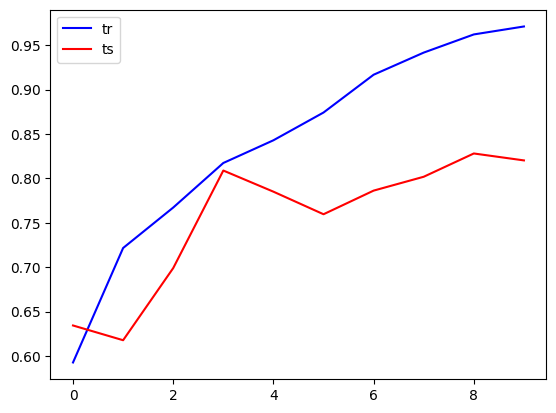

In [31]:
plt.plot(train_details.history['accuracy'], color='blue', label='tr')
plt.plot(train_details.history['val_accuracy'], color='red', label='ts')
plt.legend()
plt.show()

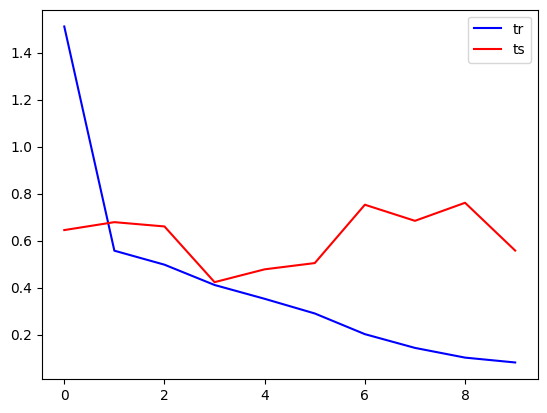

In [32]:
plt.plot(train_details.history['loss'], color='blue', label='tr')
plt.plot(train_details.history['val_loss'], color='red', label='ts')
plt.legend()
plt.show()

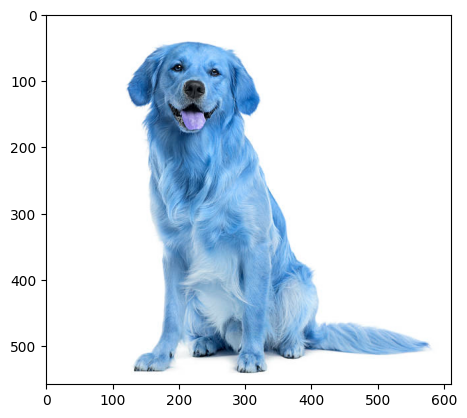

In [34]:
img = cv2.imread('/content/dog.jpg')
plt.imshow(img)

In [35]:
img.shape

(558, 612, 3)

In [36]:
img = cv2.resize(img, (256,256))
img = img.reshape((1,256,256,3))

model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step


array([[1.]], dtype=float32)